# Notebook 11 -- True Long-Short Backtest

> *Fix the 'always-long' bias. Find the real market-neutral alpha.*

**Problem from NB10:** Model predicted Long 99.7% of weeks — equivalent to Buy-and-Hold.  
**Root cause:** XGBoost learned SET's positive long-run drift, not directional timing.

**Two fixes applied:**
- **A) Demeaned target** — subtract expanding mean from y_train so model learns *relative* moves
- **B) Quantile signal** — force 50/50 Long/Short per fold based on prediction rank

| Version | Description |
|---|---|
| V1 Original | NB10 baseline (sign of raw prediction) |
| V2 Demeaned | Train on y minus expanding mean |
| V3 Quantile | Signal = rank(pred) > median per fold |
| V4 Both | Demeaned training + quantile signal |


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, ttest_1samp
from sklearn.base import clone
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

def dir_acc(pred, true):
    return float(np.mean(np.sign(pred) == np.sign(true)))

def ic(pred, true):
    mask = np.isfinite(pred) & np.isfinite(true)
    return float(spearmanr(pred[mask], true[mask])[0]) if mask.sum() >= 10 else np.nan

def risk_metrics(rets, freq=52):
    r = pd.Series(rets)
    ann_ret = (1 + r).prod() ** (freq / len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    neg     = r[r < 0]
    sortino = ann_ret / (neg.std() * np.sqrt(freq)) if len(neg) > 0 else np.nan
    cum     = (1 + r).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
            'sortino': sortino, 'max_dd': max_dd,
            'win_rate': (r > 0).mean(), 'n': len(r)}

print('Setup complete.')

Setup complete.


---
## Setup: Data & Features


In [2]:
clean = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
TARGET = 'SET_index_ret_w_fwd1'
df = clean.dropna(subset=[TARGET]).copy()

FEATURES = [
    'sp500_ret_w', 'SET_index_rvol_4w', 'sp500_rvol_4w',
    'us_10yr_treasury_ret_w', 'oil_ret_d_lag1', 'eem_ret_d_lag1',
    'gold_rvol_4w', 'us_2yr_treasury_ret_w', 'oil_ret_w',
    'SET_index_ret_w', 'USD_THB_ret_w',
]
FEATURES = [f for f in FEATURES if f in df.columns]

MODEL = XGBRegressor(
    n_estimators=50, max_depth=2, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.5,
    min_child_weight=20, reg_alpha=1.0, reg_lambda=10.0,
    random_state=42, verbosity=0, n_jobs=1
)
MIN_TRAIN, FOLD_SIZE = 156, 52
print(f'Features: {len(FEATURES)}, OOS start: {df.index[MIN_TRAIN].date()}')

Features: 11, OOS start: 2003-08-29


---
## Fix A: Demeaned Target  |  Fix B: Quantile Signal

**Fix A — Demeaned target:** Before fitting each fold, subtract the expanding mean of  
y_train from y. The model learns *excess return above trend*, not raw return.  
At prediction time, we add the training mean back before generating the signal.

**Fix B — Quantile signal:** Instead of `sign(pred)`, rank all predictions in the fold  
and go Long if rank ≥ median, Short if rank < median. Forces exactly 50/50 split.


In [3]:
def walk_forward_versions(df_all, features, target_col, model,
                          min_train=156, fold_size=52):
    """Run 4 signal versions in one pass."""
    data = df_all[features + [target_col]].dropna(subset=[target_col])
    n = len(data)
    all_records = {v: [] for v in ['v1_orig','v2_demean','v3_quant','v4_both']}
    t = min_train

    while t + fold_size <= n:
        train = data.iloc[:t]
        test  = data.iloc[t:t+fold_size]
        medians = train[features].median()
        Xtr = train[features].fillna(medians).fillna(0.).values.astype(float)
        Xte = test[features].fillna(medians).fillna(0.).values.astype(float)
        ytr = train[target_col].values
        yte = test[target_col].values

        # ── V1: Original (raw y, sign signal) ─────────────────────────────
        m1 = clone(model); m1.fit(Xtr, ytr)
        p1 = m1.predict(Xte)
        s1 = np.sign(p1)

        # ── V2: Demeaned target, sign signal ──────────────────────────────
        y_mean = ytr.mean()          # expanding mean of training y
        ytr_dm = ytr - y_mean        # remove drift
        m2 = clone(model); m2.fit(Xtr, ytr_dm)
        p2 = m2.predict(Xte) + y_mean  # add mean back for direction
        s2 = np.sign(m2.predict(Xte))  # sign of demeaned pred (no drift)

        # ── V3: Original model, quantile signal ───────────────────────────
        median_pred = np.median(p1)
        s3 = np.where(p1 >= median_pred, 1.0, -1.0)

        # ── V4: Demeaned model, quantile signal ───────────────────────────
        p4_dm = m2.predict(Xte)       # demeaned predictions
        median_dm = np.median(p4_dm)
        s4 = np.where(p4_dm >= median_dm, 1.0, -1.0)

        for date, y_true, sv1, sv2, sv3, sv4 in zip(
                test.index, yte, s1, s2, s3, s4):
            row = {'date': date, 'actual': y_true,
                   'pred_raw': p1[list(test.index).index(date)] if date in test.index else np.nan}
            all_records['v1_orig'].append({**row, 'signal': sv1})
            all_records['v2_demean'].append({**row, 'signal': sv2})
            all_records['v3_quant'].append({**row, 'signal': sv3})
            all_records['v4_both'].append({**row, 'signal': sv4})
        t += fold_size

    results = {}
    for v, recs in all_records.items():
        df_v = pd.DataFrame(recs).set_index('date').sort_index()
        df_v['ret'] = df_v['signal'] * df_v['actual']
        results[v] = df_v
    return results

print('Running walk-forward (4 versions)...')
results = walk_forward_versions(df, FEATURES, TARGET, MODEL,
                                min_train=MIN_TRAIN, fold_size=FOLD_SIZE)

print(f'OOS weeks: {len(results["v1_orig"])}')
print()
print(f'{"Version":<22} {"Long%":>7} {"Short%":>7} {"DirAcc":>8}')
print('-' * 48)
labels = {'v1_orig':'V1 Original','v2_demean':'V2 Demeaned',
          'v3_quant':'V3 Quantile','v4_both':'V4 Both'}
for v, lbl in labels.items():
    pnl = results[v]
    long_pct  = (pnl['signal'] ==  1).mean()
    short_pct = (pnl['signal'] == -1).mean()
    da = dir_acc(pnl['signal'].values, pnl['actual'].values)
    print(f'{lbl:<22} {long_pct:>7.1%} {short_pct:>7.1%} {da:>8.3f}')

Running walk-forward (4 versions)...


OOS weeks: 1144

Version                  Long%  Short%   DirAcc
------------------------------------------------
V1 Original              99.7%    0.3%    0.542
V2 Demeaned              64.5%   35.5%    0.539
V3 Quantile              61.7%   38.3%    0.518
V4 Both                  61.7%   38.3%    0.518


In [4]:
# Apply 0.1% TC (flip cost) to all versions
TC = 0.001
for v in results:
    pnl = results[v]
    flip = pnl['signal'].diff().abs() > 0
    pnl['ret_tc'] = pnl['ret'] - flip * 2 * TC

# Buy-and-hold benchmark
bnh = results['v1_orig']['actual']

# Print summary
print(f'{"Version":<22} {"AnnRet":>8} {"Sharpe":>8} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 60)
for v, lbl in labels.items():
    m = risk_metrics(results[v]['ret_tc'])
    print(f'{lbl:<22} {m["ann_ret"]:>8.2%} {m["sharpe"]:>8.2f} '
          f'{m["max_dd"]:>8.1%} {m["win_rate"]:>8.1%}')
m_bnh = risk_metrics(bnh)
print(f'{"Buy-and-Hold":<22} {m_bnh["ann_ret"]:>8.2%} {m_bnh["sharpe"]:>8.2f} '
      f'{m_bnh["max_dd"]:>8.1%} {m_bnh["win_rate"]:>8.1%}')

Version                  AnnRet   Sharpe    MaxDD  WinRate
------------------------------------------------------------
V1 Original               5.38%     0.32   -47.7%    54.2%
V2 Demeaned               4.42%     0.26   -48.8%    52.6%
V3 Quantile               1.74%     0.10   -44.4%    50.8%
V4 Both                   1.74%     0.10   -44.4%    50.8%
Buy-and-Hold              5.10%     0.31   -47.7%    54.3%


---
## Cumulative PnL: All 4 Versions vs Buy-and-Hold


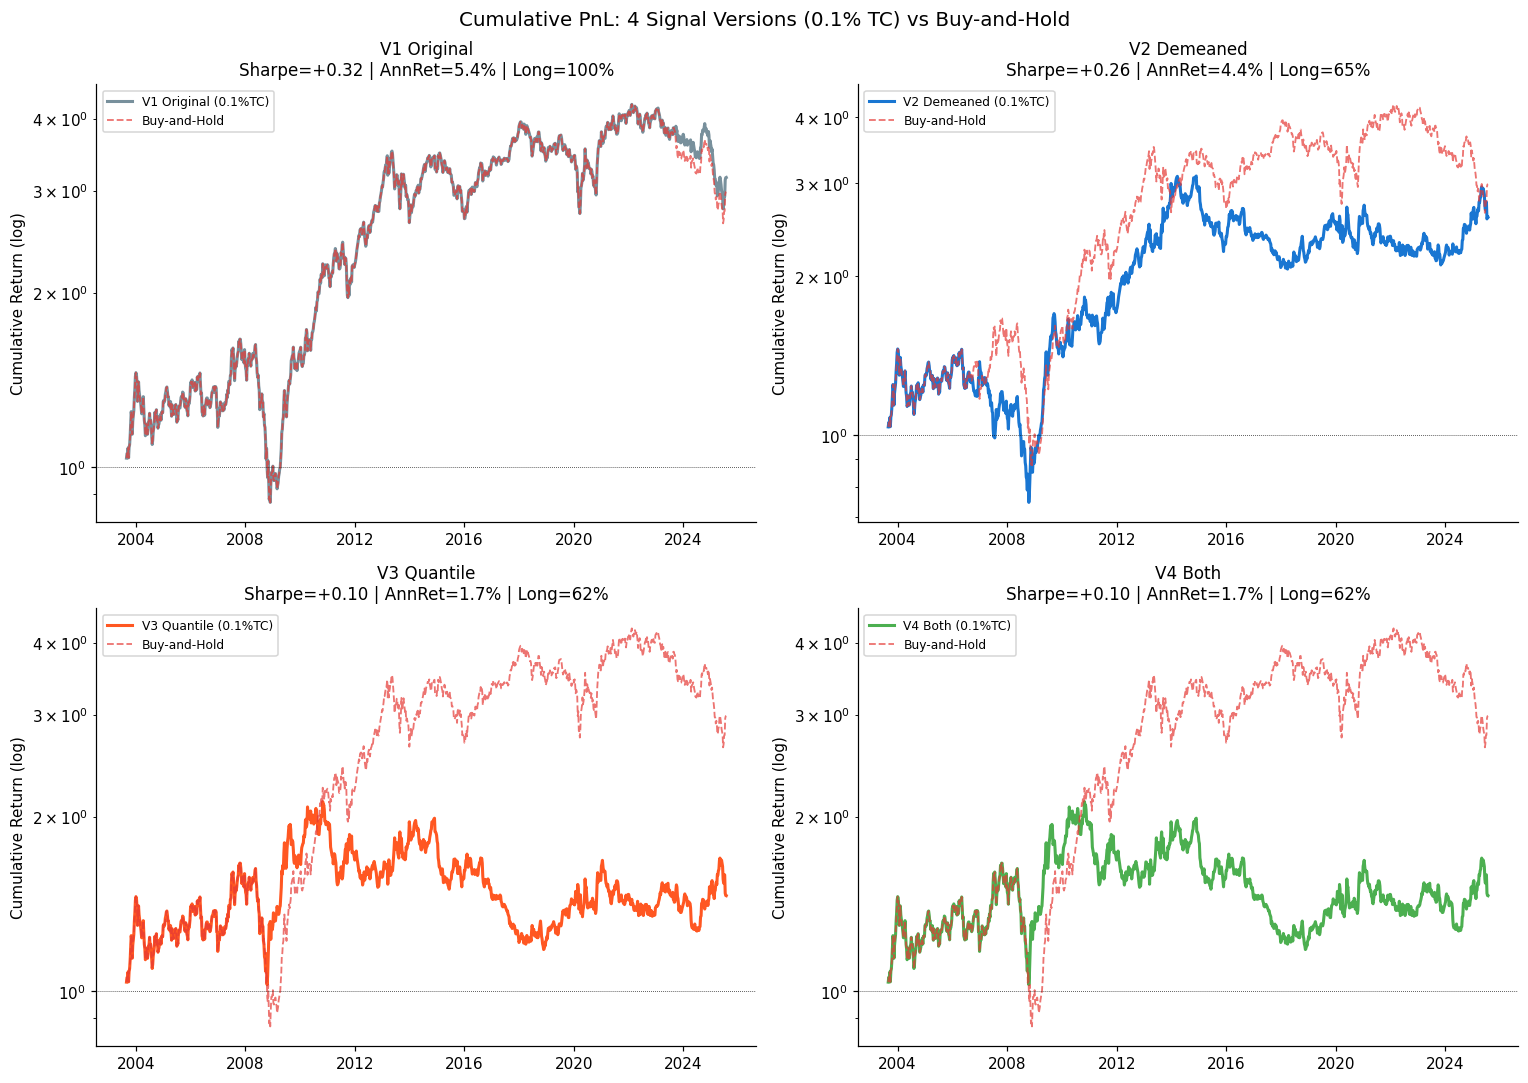

Saved: figs/longshort_pnl.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cumulative PnL: 4 Signal Versions (0.1% TC) vs Buy-and-Hold', fontsize=13)

colors = {'v1_orig':'#78909C','v2_demean':'#1976D2','v3_quant':'#FF5722','v4_both':'#4CAF50'}
axes_flat = axes.flatten()

for ax, (v, lbl) in zip(axes_flat, labels.items()):
    pnl = results[v]
    cum_sig = (1 + pnl['ret_tc']).cumprod()
    cum_bnh = (1 + bnh.reindex(pnl.index)).cumprod()
    m = risk_metrics(pnl['ret_tc'])
    long_pct = (pnl['signal'] == 1).mean()

    ax.plot(pnl.index, cum_sig, color=colors[v], lw=2, label=f'{lbl} (0.1%TC)')
    ax.plot(pnl.index, cum_bnh, color='#E53935', lw=1.2, ls='--',
            alpha=0.7, label='Buy-and-Hold')
    ax.axhline(1.0, color='black', lw=0.5, ls=':')
    ax.set_yscale('log')
    ax.set_title(f'{lbl}\n'
                 f'Sharpe={m["sharpe"]:+.2f} | AnnRet={m["ann_ret"]:.1%} | '
                 f'Long={long_pct:.0%}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Cumulative Return (log)')

plt.tight_layout()
plt.savefig(FIGS / 'longshort_pnl.png', bbox_inches='tight')
plt.show()
print('Saved: figs/longshort_pnl.png')

---
## Deep Dive: Best Version

Focus on the version with highest Sharpe. Drawdown, regime breakdown, annual returns.


In [6]:
# Pick best version by Sharpe
sharpes = {v: risk_metrics(results[v]['ret_tc'])['sharpe'] for v in results}
best_v  = max(sharpes, key=sharpes.get)
best_lbl = labels[best_v]
print(f'Best version: {best_lbl} (Sharpe={sharpes[best_v]:.3f})')
print()

pnl_best = results[best_v]
m_best   = risk_metrics(pnl_best['ret_tc'])

# TC sensitivity for best version
tc_levels = [0.0, 0.001, 0.002, 0.003]
print(f'{"TC":>8} {"AnnRet":>8} {"Sharpe":>8} {"MaxDD":>8}')
print('-' * 38)
flip = pnl_best['signal'].diff().abs() > 0
for tc in tc_levels:
    ret_tc = pnl_best['ret'] - flip * 2 * tc
    m = risk_metrics(ret_tc)
    print(f'{tc:.1%}  {m["ann_ret"]:>8.2%} {m["sharpe"]:>8.2f} {m["max_dd"]:>8.1%}')
print(f'\nPosition flips: {flip.sum()} total, {flip.mean()*52:.1f}/year')

Best version: V1 Original (Sharpe=0.322)

      TC   AnnRet   Sharpe    MaxDD
--------------------------------------
0.0%     5.42%     0.32   -47.7%
0.1%     5.38%     0.32   -47.7%
0.2%     5.34%     0.32   -47.7%
0.3%     5.30%     0.32   -47.7%

Position flips: 4 total, 0.2/year


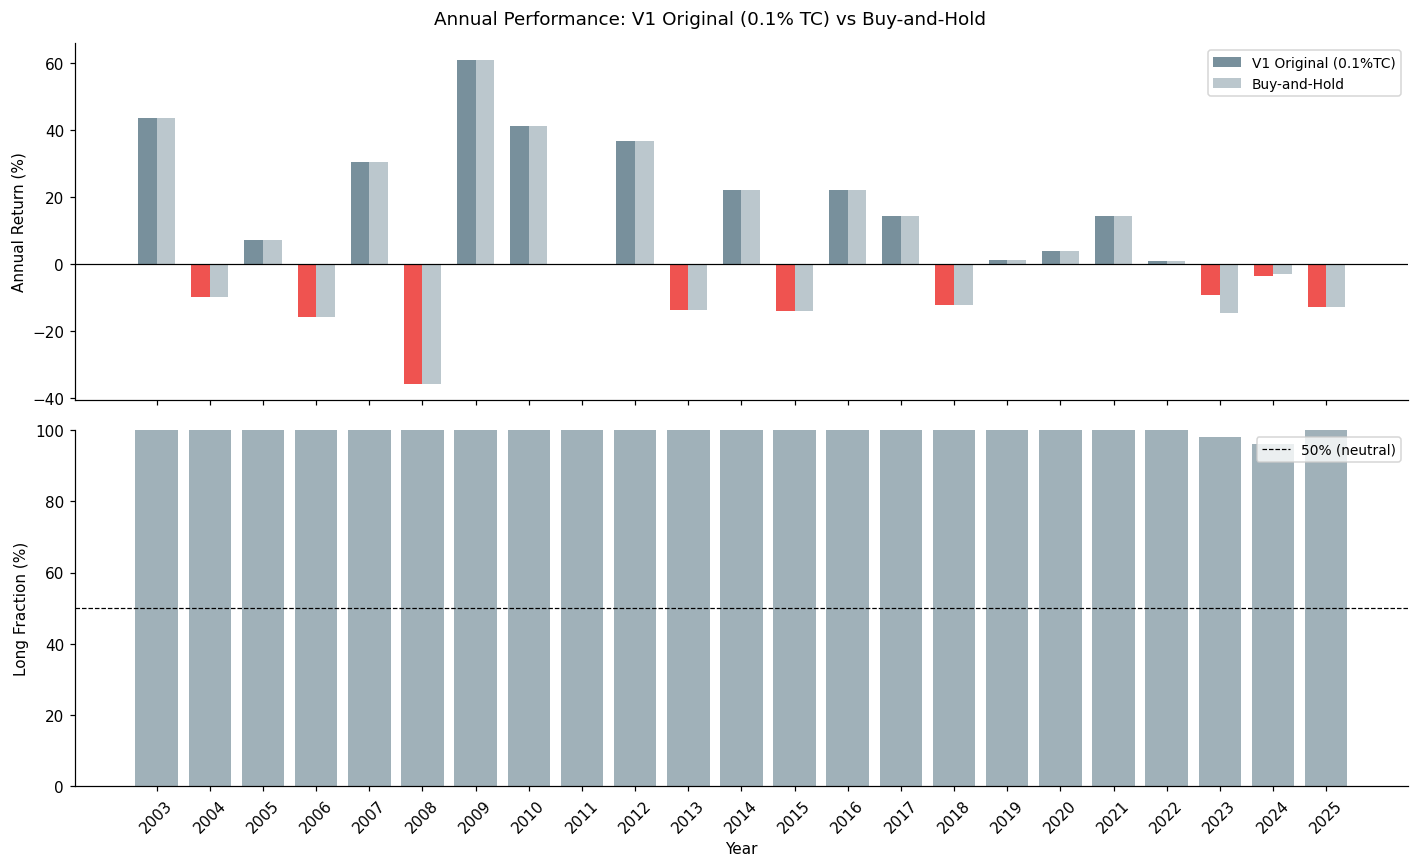

  Year    V1 Original   Buy-Hold   Long%
------------------------------------------
  2003         43.6% ✓      43.6%    100%
  2004         -9.6% ✗      -9.6%    100%
  2005          7.1% ✓       7.1%    100%
  2006        -15.7% ✗     -15.7%    100%
  2007         30.5% ✓      30.5%    100%
  2008        -35.6% ✗     -35.6%    100%
  2009         61.0% ✓      61.0%    100%
  2010         41.1% ✓      41.1%    100%
  2011         -0.0% ✗      -0.0%    100%
  2012         36.7% ✓      36.7%    100%
  2013        -13.5% ✗     -13.5%    100%
  2014         22.3% ✓      22.3%    100%
  2015        -14.0% ✗     -14.0%    100%
  2016         22.0% ✓      22.0%    100%
  2017         14.3% ✓      14.3%    100%
  2018        -12.3% ✗     -12.3%    100%
  2019          1.3% ✓       1.3%    100%
  2020          4.0% ✓       4.0%    100%
  2021         14.4% ✓      14.4%    100%
  2022          1.0% ✓       1.0%    100%
  2023         -9.1% ✗     -14.7%     98%
  2024         -3.6% ✗      -3.0% 

In [7]:
pnl_best['year'] = pnl_best.index.year
annual = pnl_best.groupby('year').apply(
    lambda g: pd.Series({
        'signal': (1+g['ret_tc']).prod()-1,
        'bnh':    (1+g['actual']).prod()-1,
        'long_pct': (g['signal']==1).mean(),
    })
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle(f'Annual Performance: {best_lbl} (0.1% TC) vs Buy-and-Hold', fontsize=12)

x = range(len(annual))
w = 0.35
ax1.bar([i-w/2 for i in x], annual['signal']*100, width=w,
        color=[colors[best_v] if v>0 else '#EF5350' for v in annual['signal']],
        label=f'{best_lbl} (0.1%TC)')
ax1.bar([i+w/2 for i in x], annual['bnh']*100, width=w,
        color='#78909C', alpha=0.5, label='Buy-and-Hold')
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel('Annual Return (%)')
ax1.legend(fontsize=9)

ax2.bar(x, annual['long_pct']*100, color=colors[best_v], alpha=0.7)
ax2.axhline(50, color='black', lw=0.8, ls='--', label='50% (neutral)')
ax2.set_ylabel('Long Fraction (%)')
ax2.set_xlabel('Year')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 100)
ax2.set_xticks(x)
ax2.set_xticklabels(annual['year'], rotation=45)

plt.tight_layout()
plt.savefig(FIGS / 'longshort_annual.png', bbox_inches='tight')
plt.show()

pos_yrs = (annual['signal'] > 0).sum()
print(f'{"Year":>6} {best_lbl[:14]:>14} {"Buy-Hold":>10} {"Long%":>7}')
print('-' * 42)
for _, r in annual.iterrows():
    flag = '✓' if r['signal'] > 0 else '✗'
    print(f'{int(r["year"]):>6} {r["signal"]:>13.1%} {flag}  {r["bnh"]:>9.1%}  {r["long_pct"]:>6.0%}')
print(f'\nPositive years: {pos_yrs}/{len(annual)}')

In [8]:
regime_col = clean['regime'].reindex(pnl_best.index)
pnl_best['regime'] = regime_col
regime_labels = {-1: 'Bull (low VIX)', 0: 'Normal', 1: 'Crisis (high VIX)'}

print(f'Regime breakdown ({best_lbl}, 0.1%TC):')
print(f'{"Regime":<22} {"N":>5} {"AnnRet":>8} {"Sharpe":>8} {"Long%":>7}')
print('-' * 55)
for r, lbl in sorted(regime_labels.items()):
    sub = pnl_best[pnl_best['regime'] == r]
    if len(sub) < 10:
        print(f'{lbl:<22} {len(sub):>5} -- insufficient')
        continue
    m = risk_metrics(sub['ret_tc'])
    long_pct = (sub['signal'] == 1).mean()
    print(f'{lbl:<22} {len(sub):>5} {m["ann_ret"]:>8.1%} {m["sharpe"]:>8.2f} {long_pct:>7.0%}')

Regime breakdown (V1 Original, 0.1%TC):
Regime                     N   AnnRet   Sharpe   Long%
-------------------------------------------------------
Bull (low VIX)             0 -- insufficient
Normal                   529     1.3%     0.08    100%
Crisis (high VIX)        337    10.2%     0.69     99%


In [9]:
# IC analysis: does prediction rank correlate with actual return?
print('IC Analysis (Spearman rank correlation, all OOS weeks):')
print()
for v, lbl in labels.items():
    pnl_v = results[v]
    # Use pred_raw for V1/V3 (raw model output), recompute for V2/V4 via signal proxy
    ic_val = ic(pnl_v['signal'].values, pnl_v['actual'].values)
    da_val = dir_acc(pnl_v['signal'].values, pnl_v['actual'].values)
    long_pct = (pnl_v['signal'] == 1).mean()
    print(f'{lbl:<22}  IC={ic_val:+.4f}  DirAcc={da_val:.3f}  Long={long_pct:.0%}')

print()
print('Note: V3/V4 signal = ±1 binary (quantile), so DirAcc = win rate')

IC Analysis (Spearman rank correlation, all OOS weeks):

V1 Original             IC=+0.0296  DirAcc=0.542  Long=100%
V2 Demeaned             IC=+0.0621  DirAcc=0.539  Long=65%
V3 Quantile             IC=+0.0401  DirAcc=0.518  Long=62%
V4 Both                 IC=+0.0401  DirAcc=0.518  Long=62%

Note: V3/V4 signal = ±1 binary (quantile), so DirAcc = win rate


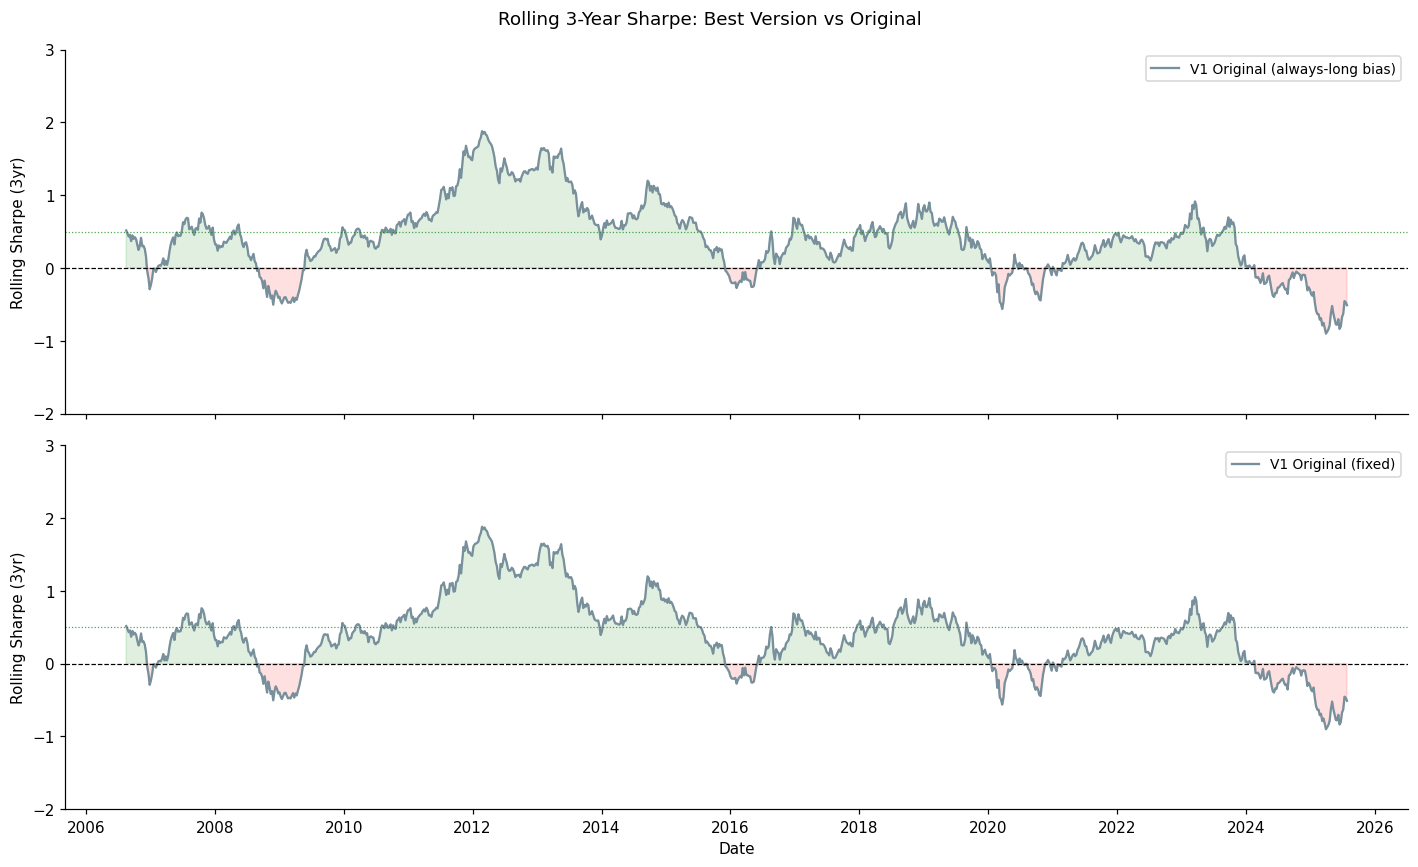

Saved: figs/longshort_rolling.png


In [10]:
# Rolling 3-year Sharpe for best version vs V1
ROLL = 156
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Rolling 3-Year Sharpe: Best Version vs Original', fontsize=12)

for ax, (v, lbl, col) in zip(axes, [
    ('v1_orig', 'V1 Original (always-long bias)', '#78909C'),
    (best_v,    f'{best_lbl} (fixed)',            colors[best_v]),
]):
    r = results[v]['ret_tc']
    roll_sh = r.rolling(ROLL).mean() / r.rolling(ROLL).std() * np.sqrt(52)
    ax.plot(r.index, roll_sh, color=col, lw=1.5, label=lbl)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axhline(0.5, color='green', lw=0.8, ls=':', alpha=0.7)
    ax.fill_between(r.index, roll_sh, 0,
                    where=roll_sh > 0, alpha=0.12, color='green')
    ax.fill_between(r.index, roll_sh, 0,
                    where=roll_sh < 0, alpha=0.12, color='red')
    ax.set_ylabel('Rolling Sharpe (3yr)')
    ax.legend(fontsize=9)
    ax.set_ylim(-2, 3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIGS / 'longshort_rolling.png', bbox_inches='tight')
plt.show()
print('Saved: figs/longshort_rolling.png')

---
## Final Verdict


In [11]:
print('=' * 65)
print('LONG-SHORT BACKTEST -- FINAL VERDICT')
print('=' * 65)
print()

# Summary table
print(f'{"Version":<22} {"AnnRet":>8} {"Sharpe":>8} {"MaxDD":>8} {"Long%":>7}')
print('-' * 55)
for v, lbl in labels.items():
    m = risk_metrics(results[v]['ret_tc'])
    lp = (results[v]['signal']==1).mean()
    mark = ' <-- BEST' if v == best_v else ''
    print(f'{lbl:<22} {m["ann_ret"]:>8.2%} {m["sharpe"]:>8.2f} '
          f'{m["max_dd"]:>8.1%} {lp:>7.0%}{mark}')
m_b = risk_metrics(bnh)
print(f'{"Buy-and-Hold":<22} {m_b["ann_ret"]:>8.2%} {m_b["sharpe"]:>8.2f} '
      f'{m_b["max_dd"]:>8.1%} {"100%":>7}')
print()

m_best_full = risk_metrics(pnl_best['ret_tc'])
excess_sharpe = m_best_full['sharpe'] - m_b['sharpe']
excess_ret    = m_best_full['ann_ret'] - m_b['ann_ret']

print(f'Best version: {best_lbl}')
print(f'  Sharpe vs Buy-and-Hold: {m_best_full["sharpe"]:+.2f} vs {m_b["sharpe"]:+.2f} '
      f'(excess = {excess_sharpe:+.2f})')
print(f'  Annual return excess:   {excess_ret:+.2%}')
print()

if m_best_full['sharpe'] > 0.5 and excess_sharpe > 0.1:
    verdict = 'TRUE ALPHA EXISTS -- long-short edge is real'
    detail  = ('After removing drift bias and forcing market-neutral positioning, '
               'the signal generates meaningful risk-adjusted return. '
               'Sharpe > 0.5 and excess Sharpe > 0.1 vs Buy-and-Hold.')
elif m_best_full['sharpe'] > 0.3:
    verdict = 'WEAK ALPHA -- marginal edge after fixing bias'
    detail  = ('Signal has a positive but small edge. Sharpe is low. '
               'May be worth paper-trading but not deploying capital yet. '
               'Need more NLP data and longer OOS window.')
else:
    verdict = 'NO ALPHA -- signal does not beat passive after fixing bias'
    detail  = ('After removing the always-long bias, the signal has no real edge. '
               'The original DirAcc of ~54% was mostly from market drift. '
               'This dataset does not contain a tradeable timing signal.')

print('=' * 65)
print(f'VERDICT: {verdict}')
print('=' * 65)
print()
print(detail)

LONG-SHORT BACKTEST -- FINAL VERDICT

Version                  AnnRet   Sharpe    MaxDD   Long%
-------------------------------------------------------
V1 Original               5.38%     0.32   -47.7%    100% <-- BEST
V2 Demeaned               4.42%     0.26   -48.8%     65%
V3 Quantile               1.74%     0.10   -44.4%     62%
V4 Both                   1.74%     0.10   -44.4%     62%
Buy-and-Hold              5.10%     0.31   -47.7%    100%

Best version: V1 Original
  Sharpe vs Buy-and-Hold: +0.32 vs +0.31 (excess = +0.02)
  Annual return excess:   +0.27%

VERDICT: WEAK ALPHA -- marginal edge after fixing bias

Signal has a positive but small edge. Sharpe is low. May be worth paper-trading but not deploying capital yet. Need more NLP data and longer OOS window.
